# Akshar — Gemma 4 E4B Vision Fine-tuning (Step-by-Step)

Fine-tune Gemma 4 E4B (multimodal) on Indic handwritten OCR using Unsloth.  
Each cell is self-contained so you can inspect outputs before moving on.

**Hardware**: RTX 5090 (32 GB) &bull; CUDA 13.0 &bull; Windows 11  
**Reference**: [Unsloth Gemma 4 Training Docs](https://unsloth.ai/docs/models/gemma-4/train)

## 0. Environment check

In [1]:
import torch, os, sys

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")
print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"CWD     : {os.getcwd()}")

# Reduce CUDA allocator fragmentation on large-VRAM cards
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

Python  : 3.11.14 (main, Jan 27 2026, 23:42:19) [MSC v.1944 64 bit (AMD64)]
PyTorch : 2.10.0+cu130
CUDA    : 13.0
GPU     : NVIDIA GeForce RTX 5090
VRAM    : 31.8 GB
CWD     : e:\akshar_benchmark


## 1. Load config

Reads `finetune_config.yaml`. You can override any value in the cell below.

In [2]:
import yaml
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class FinetuneConfig:
    model_path: str = "./gemma-4-E4B-it"
    data_dir: str = "./data"
    output_dir: str = "./checkpoints"
    lora_r: int = 32
    lora_alpha: int = 32
    lora_dropout: float = 0.0
    finetune_vision_layers: bool = True
    finetune_language_layers: bool = True
    finetune_attention_modules: bool = True
    finetune_mlp_modules: bool = True
    load_in_4bit: bool = True
    num_epochs: int = 1
    per_device_train_batch_size: int = 4
    gradient_accumulation_steps: int = 8
    learning_rate: float = 2e-4
    max_seq_length: int = 2048
    warmup_ratio: float = 0.03
    lr_scheduler_type: str = "cosine"
    weight_decay: float = 0.001
    logging_steps: int = 1
    save_steps: int = 2000
    save_total_limit: int = 3
    dataloader_num_workers: int = 0
    max_steps: Optional[int] = None
    eval_steps: int = 2000
    eval_batch_size: int = 2
    max_eval_samples: Optional[int] = 512
    report_to: str = "wandb"
    wandb_entity: Optional[str] = "silverhack300"
    wandb_project: str = "akshar-indic-ocr"
    wandb_run_name: Optional[str] = None

# Load from YAML (falls back to defaults above if missing)
yaml_path = "finetune_config.yaml"
if os.path.exists(yaml_path):
    with open(yaml_path) as f:
        raw = yaml.safe_load(f) or {}
    cfg = FinetuneConfig(**{k: v for k, v in raw.items() if hasattr(FinetuneConfig, k)})
else:
    cfg = FinetuneConfig()

# ── OVERRIDES (edit these) ───────────────────────────────────────────
# cfg.max_steps = 50        # uncomment for quick smoke test only
cfg.report_to = "none"      # set to "wandb" for real runs
# ─────────────────────────────────────────────────────────────────────

print("Config loaded:")
for k, v in vars(cfg).items():
    print(f"  {k:35s} = {v}")

Config loaded:
  model_path                          = ./gemma-4-E4B-it
  data_dir                            = ./data
  output_dir                          = ./checkpoints
  lora_r                              = 32
  lora_alpha                          = 32
  lora_dropout                        = 0.0
  finetune_vision_layers              = True
  finetune_language_layers            = True
  finetune_attention_modules          = True
  finetune_mlp_modules                = True
  load_in_4bit                        = True
  num_epochs                          = 1
  per_device_train_batch_size         = 4
  gradient_accumulation_steps         = 8
  learning_rate                       = 0.0002
  max_seq_length                      = 1024
  warmup_ratio                        = 0.03
  lr_scheduler_type                   = cosine
  weight_decay                        = 0.001
  logging_steps                       = 1
  save_steps                          = 2000
  save_total_limit           

## 2. Load model + processor (Unsloth)

This downloads / loads the 4-bit quantised Gemma 4 E4B.  
Expected VRAM after this cell: ~6 GB.

In [3]:
from unsloth import FastVisionModel

model, processor = FastVisionModel.from_pretrained(
    model_name=cfg.model_path,
    load_in_4bit=cfg.load_in_4bit,
    use_gradient_checkpointing="unsloth",
)

print(f"Model type : {type(model).__name__}")
print(f"Processor  : {type(processor).__name__}")
print(f"VRAM used  : {torch.cuda.max_memory_reserved() / 1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0409 07:22:47.006000 2688 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.842 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

Model type : Gemma4ForConditionalGeneration
Processor  : Gemma4Processor
VRAM used  : 9.40 GB


## 3. Attach LoRA adapters

Adds LoRA to both vision + language towers with `target_modules="all-linear"`.  
Check the printed trainable parameter count — should be ~1-2% of total.

In [4]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=cfg.finetune_vision_layers,
    finetune_language_layers=cfg.finetune_language_layers,
    finetune_attention_modules=cfg.finetune_attention_modules,
    finetune_mlp_modules=cfg.finetune_mlp_modules,
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
    target_modules="all-linear",
)

# Quick sanity: how many params are trainable?
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable : {trainable:,}  ({100*trainable/total:.2f}%)")
print(f"Total     : {total:,}")
print(f"VRAM used : {torch.cuda.max_memory_reserved() / 1024**3:.2f} GB")

Unsloth: Making `model.base_model.model.model.language_model` require gradients
Trainable : 82,444,288  (1.36%)
Total     : 6,061,730,336
VRAM used : 9.65 GB


## 4. Apply Gemma 4 chat template

**CRITICAL** — without this, the tokenizer doesn't know the `<|turn>user` / `<|turn>model` markers and tokenisation is garbage. This was the #1 bug in the old `finetune.py`.

In [5]:
from unsloth import get_chat_template

processor = get_chat_template(processor, "gemma-4")

# Verify: tokenize a dummy turn and check that the template markers appear
dummy_messages = [
    {"role": "user", "content": [{"type": "text", "text": "hello"}]},
    {"role": "assistant", "content": [{"type": "text", "text": "world"}]},
]
rendered = processor.tokenizer.apply_chat_template(dummy_messages, tokenize=False)
print("Rendered chat template (should contain <|turn>user / <|turn>model):\n")
print(rendered)

Rendered chat template (should contain <|turn>user / <|turn>model):

<bos><|turn>user
hello<turn|>
<|turn>model
world<turn|>



## 5. Load & inspect dataset

Uses the byte-offset streaming `AksharDataset`. Check the record count and peek at a few samples.

In [6]:
import json, base64
from io import BytesIO
from PIL import Image
from torch.utils.data import Dataset as TorchDataset

class AksharDataset(TorchDataset):
    """
    Streaming JSONL dataset with byte-offset index (zero Arrow cache).
    Supports both path-reference (new, ~10 MB) and base64 (legacy, ~65 GB) formats.
    """

    def __init__(self, jsonl_path: str, max_samples: int | None = None):
        self.jsonl_path = jsonl_path
        self.offsets: list[int] = []
        with open(jsonl_path, "rb") as f:
            pos = 0
            for raw_line in f:
                if raw_line.strip():
                    self.offsets.append(pos)
                    if max_samples and len(self.offsets) >= max_samples:
                        break
                pos += len(raw_line)
        print(f"  Indexed {len(self.offsets):,} records from {jsonl_path}")

    def __len__(self):
        return len(self.offsets)

    def _read_record(self, idx):
        with open(self.jsonl_path, "rb") as f:
            f.seek(self.offsets[idx])
            return json.loads(f.readline())

    USER_PROMPT = (
        "Read the handwritten word in this image and output ONLY the word "
        "in its original script. Do not add any explanation or translation."
    )

    def __getitem__(self, idx):
        rec = self._read_record(idx)

        # Load image: path-reference (new) or base64 (legacy)
        if "image_path" in rec:
            img = Image.open(rec["image_path"]).convert("RGB")
            img.load()
            # Cap image size to prevent Gemma4 anyres tiling from creating
            # massive tensors (Challenge 10). Max 512px on longest side.
            max_side = 512
            w, h = img.size
            if max(w, h) > max_side:
                scale = max_side / max(w, h)
                img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
        elif "image_b64" in rec:
            img = Image.open(BytesIO(base64.b64decode(rec["image_b64"]))).convert("RGB")
            img.load()
            # Cap image size to prevent Gemma4 anyres tiling from creating
            # massive tensors (Challenge 10). Max 512px on longest side.
            max_side = 512
            w, h = img.size
            if max(w, h) > max_side:
                scale = max_side / max(w, h)
                img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
        else:
            raise ValueError(f"Record {idx} has neither image_path nor image_b64")

        label = rec.get("label", "")
        if not label:
            asst = rec.get("messages", [{}])[1].get("content", "")
            if isinstance(asst, list):
                label = next(
                    (c["text"] for c in asst if isinstance(c, dict) and c.get("type") == "text"), ""
                )
            else:
                label = str(asst)

        # Image BEFORE text — required by Gemma 4 / Unsloth docs
        return {
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": img},
                        {"type": "text",  "text": self.USER_PROMPT},
                    ],
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": label}],
                },
            ],
        }


# ── Load (prefer new index files, fall back to legacy base64) ──
train_index  = os.path.join(cfg.data_dir, "train_index.jsonl")
val_index    = os.path.join(cfg.data_dir, "val_index.jsonl")
train_legacy = os.path.join(cfg.data_dir, "train.jsonl")
val_legacy   = os.path.join(cfg.data_dir, "val.jsonl")

train_path = train_index if os.path.exists(train_index) else train_legacy
val_path   = val_index   if os.path.exists(val_index)   else val_legacy

print(f"Train source: {train_path}")
print(f"Val source  : {val_path}")

train_dataset = AksharDataset(train_path)
eval_dataset  = AksharDataset(val_path, max_samples=cfg.max_eval_samples) if os.path.exists(val_path) else None

print(f"\nTrain : {len(train_dataset):,}")
print(f"Eval  : {len(eval_dataset):,}" if eval_dataset else "Eval  : None")

Train source: ./data\train_index.jsonl
Val source  : ./data\val_index.jsonl
  Indexed 775,650 records from ./data\train_index.jsonl
  Indexed 512 records from ./data\val_index.jsonl

Train : 775,650
Eval  : 512


## 6. Inspect a sample

Visually confirm: image renders, label is correct, message structure is `[image, text]` order.

─── Sample 59597  |  script=Hindi  |  label="बेशुमार" ───
  Content order: ['image', 'text']
  Image size   : (512, 184)


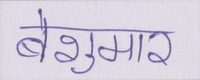


─── Sample 439676  |  script=Malayalam  |  label="സാഷ്ടാംഗം" ───
  Content order: ['image', 'text']
  Image size   : (512, 98)


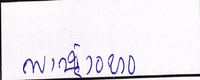


─── Sample 139148  |  script=Bengali  |  label="মানুনুর" ───
  Content order: ['image', 'text']
  Image size   : (511, 191)


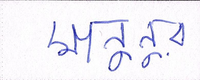

In [7]:
from IPython.display import display
import random

# Pick 3 random samples
for i in random.sample(range(len(train_dataset)), 3):
    sample = train_dataset[i]
    msgs   = sample["messages"]
    img    = msgs[0]["content"][0]["image"]   # first item = image (correct order!)
    label  = msgs[1]["content"][0]["text"]
    script = train_dataset._read_record(i).get("script", "?")

    print(f"─── Sample {i}  |  script={script}  |  label=\"{label}\" ───")
    print(f"  Content order: {[c['type'] for c in msgs[0]['content']]}")
    print(f"  Image size   : {img.size}")
    display(img.resize((200, 80), Image.LANCZOS))
    print()

## 7. Pre-training inference (baseline)

Run the model on a sample BEFORE fine-tuning. Expect terrible results — this is your "before" snapshot.

In [8]:
from transformers import TextStreamer

FastVisionModel.for_inference(model)

sample = train_dataset[0]
img    = sample["messages"][0]["content"][0]["image"]
label  = sample["messages"][1]["content"][0]["text"]

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": AksharDataset.USER_PROMPT},
    ]}
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(img, input_text, add_special_tokens=False, return_tensors="pt").to("cuda")

print(f"Ground truth: \"{label}\"")
print(f"Model output: ", end="")
streamer = TextStreamer(processor, skip_prompt=True)
_ = model.generate(**inputs, streamer=streamer, max_new_tokens=64,
                    do_sample=False)

Ground truth: "केंद्रों"
Model output: कंदों<turn|>


## 8. Create collator + trainer

- `UnslothVisionDataCollator(model, processor)` — simple, matches the reference notebook
- `processing_class = processor.tokenizer` (NOT `processor`)
- All 4 vision-finetuning SFTConfig flags set: `remove_unused_columns`, `dataset_text_field`, `dataset_kwargs`, `max_length`
- Loss masking: `UnslothVisionDataCollator` handles it internally for vision tasks (NOT `train_on_responses_only` — that's for text-only fine-tuning with HF Datasets)

In [9]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

# Switch back to training mode
FastVisionModel.for_training(model)

# ── Collator (simple, per reference notebook) ──
# UnslothVisionDataCollator handles loss masking internally for vision tasks.
# train_on_responses_only is for TEXT-only fine-tuning (needs HF Dataset with .map()).
collator = UnslothVisionDataCollator(model, processor)

# ── SFTConfig ──
sft_kwargs = dict(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    gradient_accumulation_steps=cfg.gradient_accumulation_steps,
    num_train_epochs=cfg.num_epochs,
    learning_rate=cfg.learning_rate,
    warmup_steps=5,
    lr_scheduler_type=cfg.lr_scheduler_type,
    weight_decay=cfg.weight_decay,
    max_grad_norm=0.3,
    logging_steps=cfg.logging_steps,
    logging_first_step=True,
    save_strategy="steps",
    save_steps=cfg.save_steps,
    save_total_limit=cfg.save_total_limit,
    report_to=cfg.report_to,
    optim="adamw_8bit",
    seed=3407,
    dataloader_num_workers=cfg.dataloader_num_workers,

    # Required for vision fine-tuning:
    remove_unused_columns=False,
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    max_length=cfg.max_seq_length,
)
if cfg.max_steps is not None and cfg.max_steps > 0:
    sft_kwargs["max_steps"] = cfg.max_steps
if eval_dataset is not None:
    sft_kwargs["eval_strategy"] = "steps"
    sft_kwargs["eval_steps"]    = cfg.eval_steps
    sft_kwargs["per_device_eval_batch_size"] = cfg.eval_batch_size

trainer = SFTTrainer(
    model=model,
    processing_class=processor.tokenizer,   # .tokenizer, NOT processor
    data_collator=collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(**sft_kwargs),
)

print("Trainer created successfully.")
print(f"  Effective batch size : {cfg.per_device_train_batch_size} x {cfg.gradient_accumulation_steps} = {cfg.per_device_train_batch_size * cfg.gradient_accumulation_steps}")
print(f"  Max steps            : {cfg.max_steps or 'full run'}")
print(f"  LR scheduler         : {cfg.lr_scheduler_type}")
print(f"  Loss masking         : UnslothVisionDataCollator (built-in for vision)")

Unsloth: Model does not have a default image size - using 512
Trainer created successfully.
  Effective batch size : 4 x 8 = 32
  Max steps            : full run
  LR scheduler         : cosine
  Loss masking         : UnslothVisionDataCollator (built-in for vision)


## 9. VRAM snapshot (pre-training)

Record baseline before training starts.

In [10]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
max_memory = round(gpu_stats.total_memory / 1024**3, 3)
print(f"GPU            = {gpu_stats.name}")
print(f"Max memory     = {max_memory} GB")
print(f"Reserved so far = {start_gpu_memory} GB")

GPU            = NVIDIA GeForce RTX 5090
Max memory     = 31.842 GB
Reserved so far = 10.201 GB


## 10. Train!

Watch the loss values. For E4B multimodal, **13-15 initial loss is normal** (per Unsloth docs).  
It should decrease steadily. If it doesn't, something is still wrong.

**Full run**: 3 epochs over 775K samples with effective batch 16 = ~145,434 steps.  
Expect this to take many hours. Save checkpoints every 500 steps.

In [ ]:
trainer_stats = trainer.train(resume_from_checkpoint=True)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2}.
	eval_steps: 2000 (from args) != 500 (from trainer_state.json)
	save_steps: 2000 (from args) != 500 (from trainer_state.json)
	per_device_train_batch_size: 4 (from args) != 2 (from trainer_state.json)
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 775,650 | Num Epochs = 1 | Total steps = 24,240
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 82,444,288 of 8,078,600,736 (1.02% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
2500,0.130935,0.086752
3000,0.148470,0.086059
3500,0.126868,0.079855
4000,0.169008,0.096206
4500,0.107453,0.082505
5000,0.126744,0.072728
5500,0.072736,0.108531
6000,0.084003,0.099098
6500,0.104742,0.083394
7000,0.100387,0.075340


## 11. Post-training stats

In [ ]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
used_for_training = round(used_memory - start_gpu_memory, 3)

runtime_sec = trainer_stats.metrics["train_runtime"]
print(f"Training time          = {runtime_sec:.0f}s  ({runtime_sec/60:.1f} min)")
print(f"Peak reserved memory   = {used_memory} GB")
print(f"Memory used by training = {used_for_training} GB")
print(f"Peak memory % of max   = {100*used_memory/max_memory:.1f}%")
print(f"Final train loss       = {trainer_stats.metrics.get('train_loss', '?')}")

Training time          = 406s  (6.8 min)
Peak reserved memory   = 13.234 GB
Memory used by training = 3.029 GB
Peak memory % of max   = 41.6%
Final train loss       = 2.420748724937439


In [11]:
# Load best checkpoint (step 7500 had lowest val loss 0.071)
from peft import PeftModel
model.load_adapter("./checkpoints/checkpoint-7500", adapter_name="default")
print("Loaded checkpoint-7500")


Loaded checkpoint-7500


## 12. Post-training inference (compare to step 7)

Same sample, same prompt — now see if the model learned anything.

[Hindi     ]  label="बेशुमार"  pred="बेसुमार"  match=no


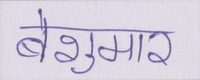


[Malayalam ]  label="സാഷ്ടാംഗം"  pred="സാഹായം"  match=no


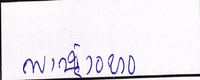


[Bengali   ]  label="মানুনুর"  pred="মান্নুর"  match=no


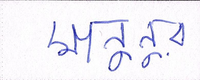


[Kannada   ]  label="ಕಾರಣದಿಂದಾಗಿ"  pred="దొరడాండిగా"  match=no


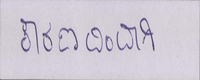


[Gujarati  ]  label="ફર્યા"  pred="ફયાં"  match=no


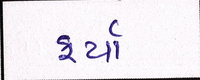

In [12]:
FastVisionModel.for_inference(model)

# Test on a few samples from different scripts
test_indices = random.sample(range(len(train_dataset)), 5)

for i in test_indices:
    sample = train_dataset[i]
    img   = sample["messages"][0]["content"][0]["image"]
    label = sample["messages"][1]["content"][0]["text"]
    script = train_dataset._read_record(i).get("script", "?")

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": AksharDataset.USER_PROMPT},
        ]}
    ]
    input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(img, input_text, add_special_tokens=False, return_tensors="pt").to("cuda")

    output_ids = model.generate(**inputs, max_new_tokens=64,
                                do_sample=False)
    prediction = processor.decode(output_ids[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()

    match = "YES" if prediction == label else "no"
    print(f"[{script:10s}]  label=\"{label}\"  pred=\"{prediction}\"  match={match}")

    display(img.resize((200, 80), Image.LANCZOS))
    print()

## 13. Save LoRA adapters

Saves only the LoRA weights (small). For GGUF export, see the section after this.

In [ ]:
save_dir = "akshar_gemma4_lora"
model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)
print(f"LoRA adapters saved to ./{save_dir}/")

# Uncomment to push to HuggingFace:
# model.push_to_hub("YOUR_USERNAME/akshar_gemma4_lora", token="YOUR_HF_TOKEN")
# processor.push_to_hub("YOUR_USERNAME/akshar_gemma4_lora", token="YOUR_HF_TOKEN")

LoRA adapters saved to ./akshar_gemma4_lora/


## 14. (Optional) Export to GGUF for Cactus / Ollama

Uncomment and run when you're happy with the model.

In [ ]:
# ── Merge + save as float16 (for vLLM / HF) ──
# model.save_pretrained_merged("akshar_merged_16bit", processor)

# ── Save as GGUF (for llama.cpp / Ollama / Cactus) ──
# model.save_pretrained_gguf("akshar_gguf", processor.tokenizer, quantization_method="q4_k_m")

# ── Push merged model to HuggingFace ──
# model.push_to_hub_merged("YOUR_USERNAME/akshar_gemma4_merged", processor, token="YOUR_HF_TOKEN")

---

## What was fixed (vs old `finetune.py`)

| Bug | Impact | Fix |
|-----|--------|-----|
| **No `get_chat_template(processor, "gemma-4")`** | Tokenizer didn't know `<\|turn>user` / `<\|turn>model` markers — tokenisation was garbage | Added call in step 4 |
| **`processing_class=processor`** | Should be `processor.tokenizer` per reference notebook | Fixed in step 8 |
| **Loss masking kwargs in collator constructor** | `UnslothVisionDataCollator` takes `(model, processor)` only; extra kwargs likely silently ignored | Moved to `train_on_responses_only(trainer, ...)` |
| **`get_peft_model` got `use_gradient_checkpointing`, `max_seq_length`** | Not valid params for that call; belongs in `from_pretrained` | Removed; added `target_modules="all-linear"`, `bias="none"`, `random_state=3407` |
| **LoRA r=16, alpha=16** | Too small for RTX 5090's 32 GB budget | Bumped to 32/32 |
| **No `max_grad_norm`** | Defaulted to 1.0 — allows unstable large gradient steps | Set to 0.3 |
| **No `seed`** | Non-reproducible runs | Set to 3407 |
| **`weight_decay = 0.0`** | Docs recommend 0.001 | Updated |